npoints=1000 ...
npoints=10000 ...
npoints=100000 ...
npoints=1000000 ...
CPU times: total: 50.4 s
Wall time: 52.1 s


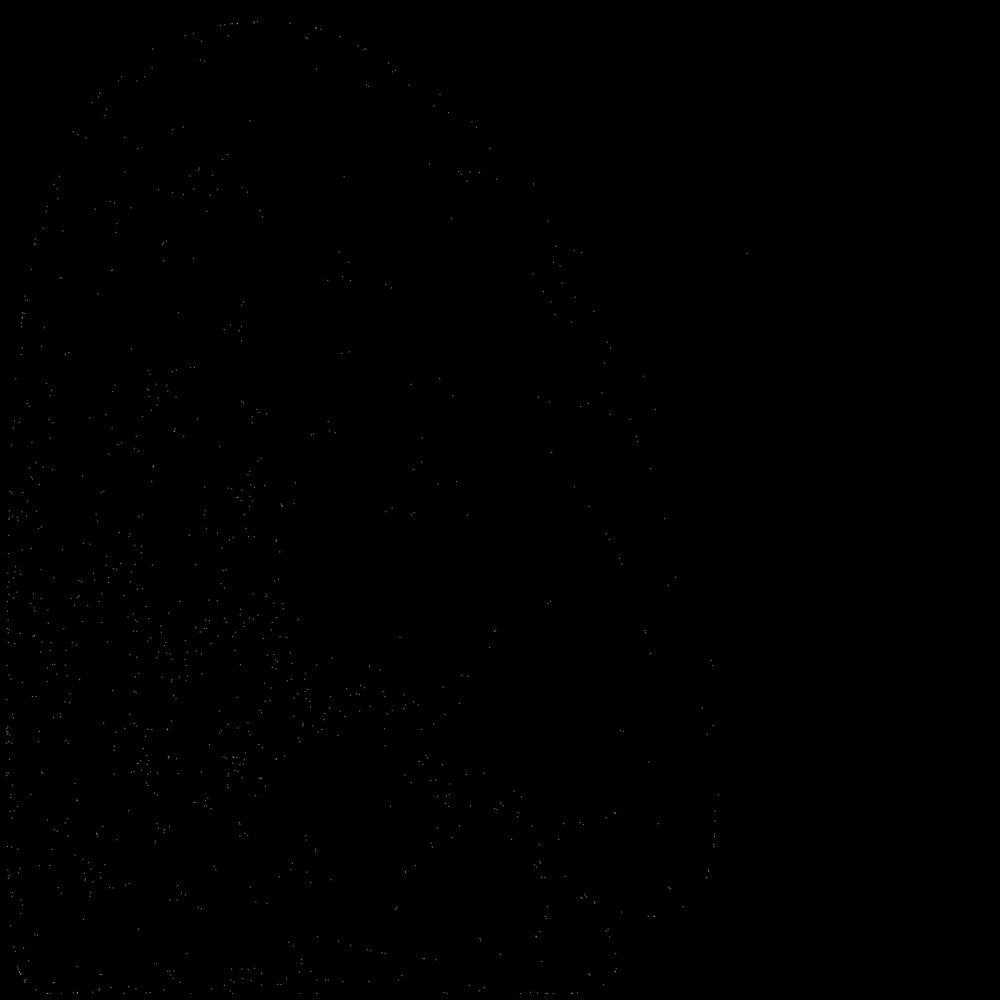

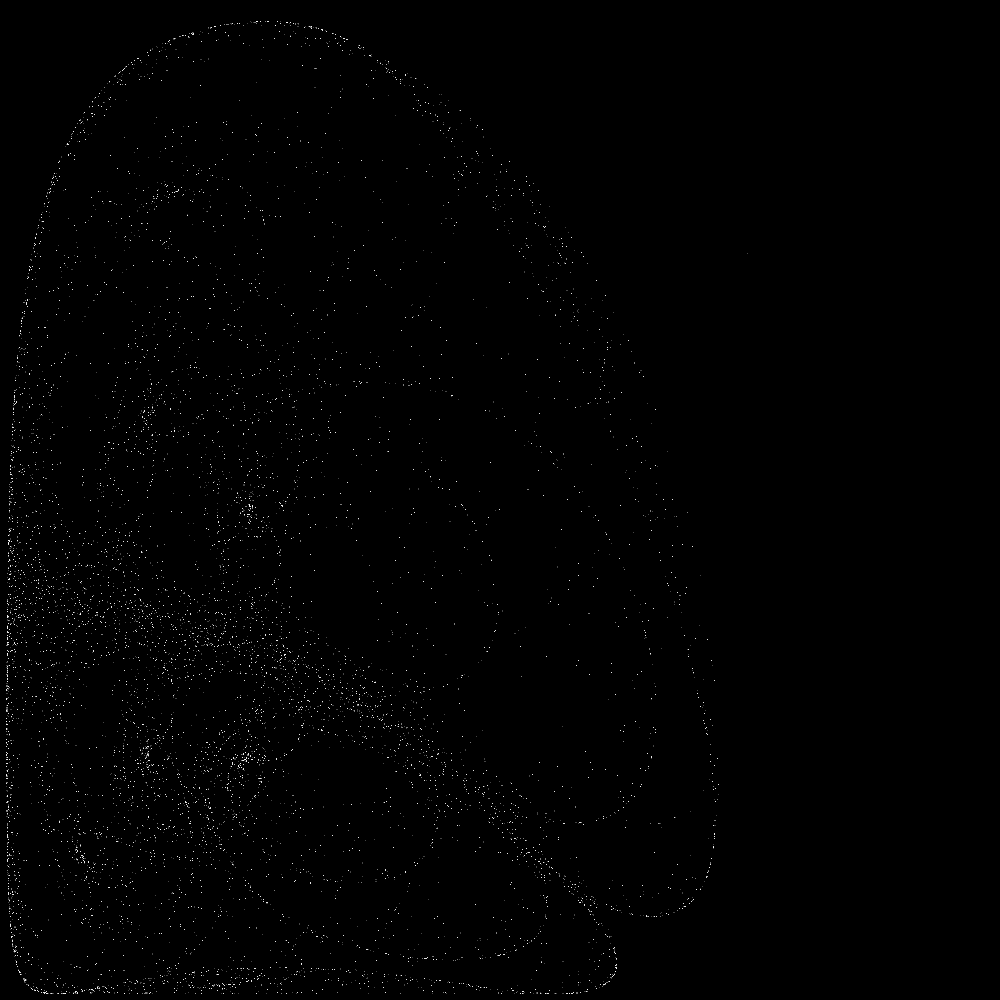

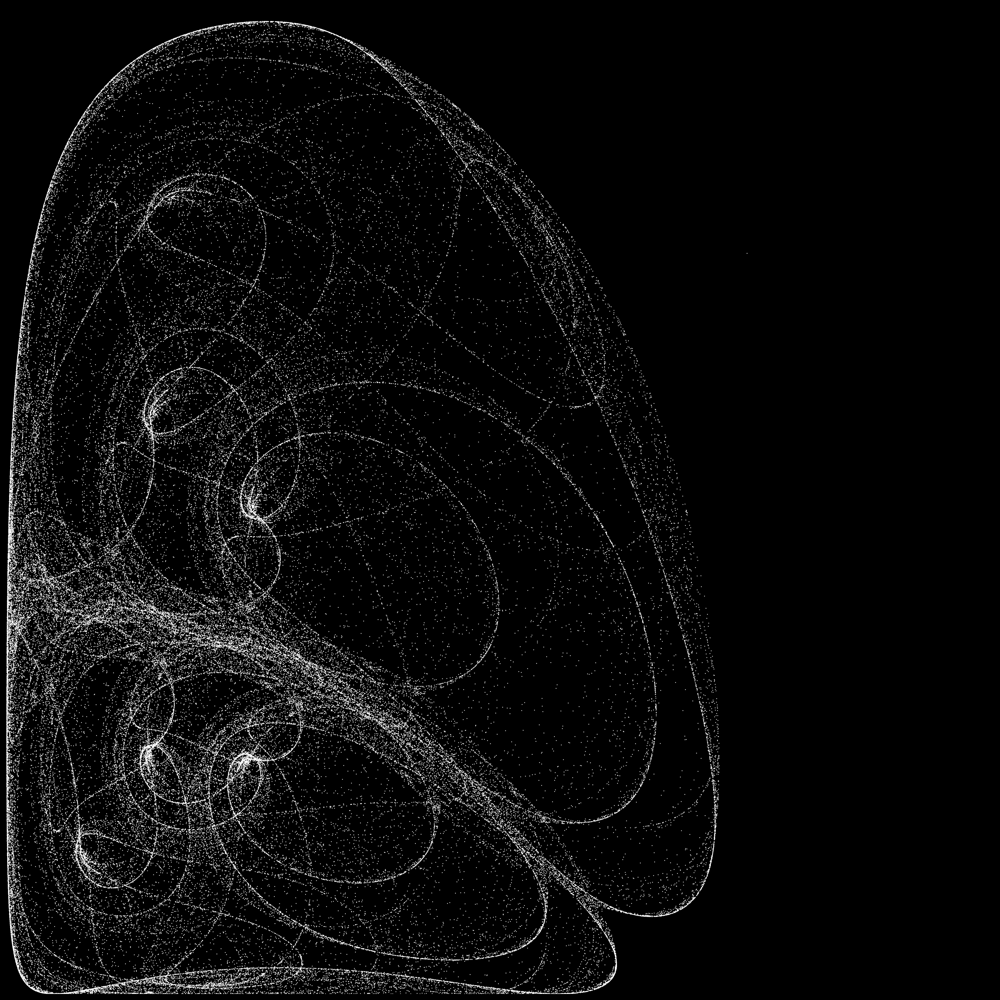

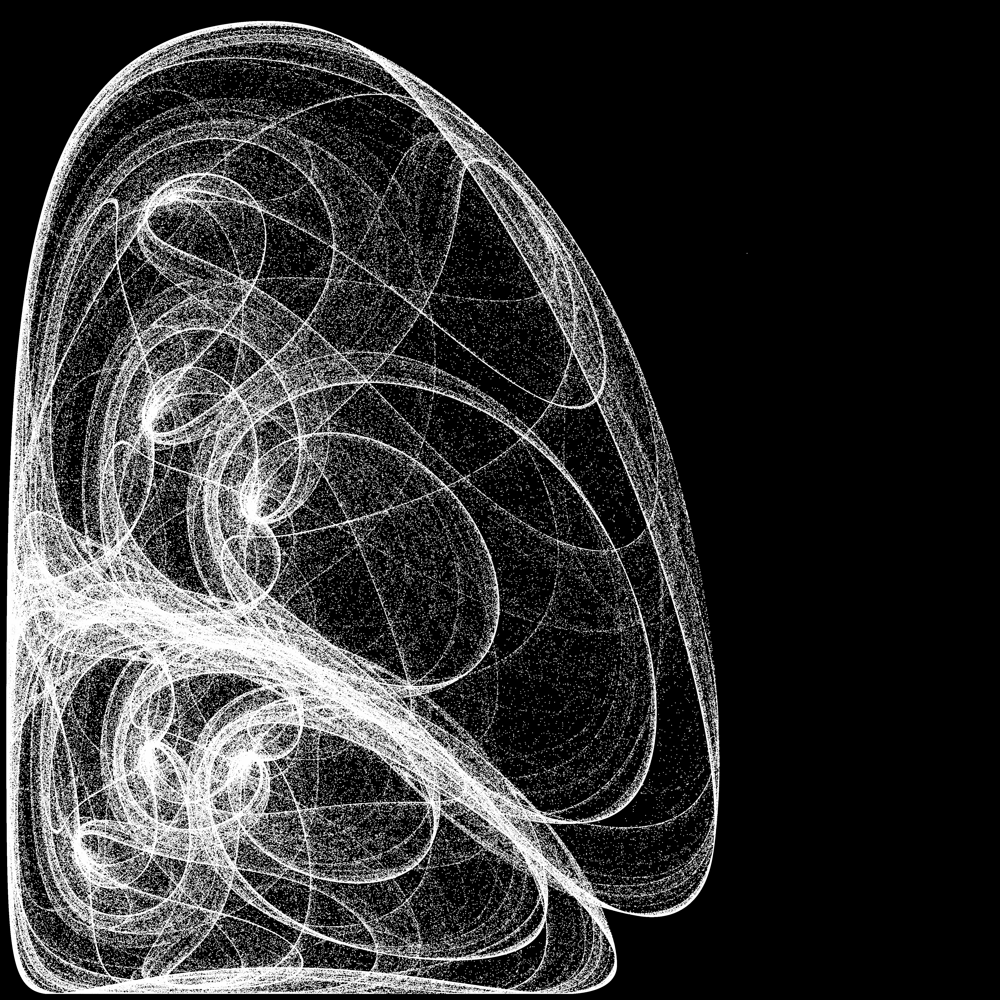

In [1]:
%%time
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigvals

def update(x, y):
    """
    (profconradi.com)
    """
    xx = np.sin(x*x - y*y + 3.682)
    yy = np.cos(2*x*y + 4.155)
    return xx, yy

def plot_points(x, y, fig=None, ax=None, line=None):
    if fig is None and ax is None:
        fig,ax = plt.subplots(figsize=(16,16), dpi=300, facecolor="k")
    #ax.scatter(x, y, s=(72./fig.dpi)**2, marker='o', facecolor='white', lw=0, alpha=0.2) #1 pixel marker
    ax.scatter(x, y, s=1, marker='o', facecolor='white', lw=0, alpha=0.9) #1 pixel marker
    ax.set(facecolor="k")
    ax.set_aspect("equal")
    ax.set(xlim=(-1,1), ylim=(-1,1))
    ax.axis('off')
    fig.tight_layout()
    return fig,ax

for npoints in [1000, 10000, 100000, 1000000]: #, 10000000]:
    print(f"npoints={npoints:d} ...")
    x, y = 0.5, 0.5
    fig,ax=None,None
    try:
        xs, ys = np.loadtxt(f"my_orbit_n{npoints}.dat", unpack=True)
    except:
        xs = [x]
        ys = [y]
        for i in range(npoints):
            x,y = update(x,y)
            xs.append(x)
            ys.append(y)
        np.savetxt(f"my_orbit_n{npoints}.dat", np.array([xs,ys]).T)
    fig,ax = plot_points(xs, ys, fig=fig, ax=ax)
    for fmt in ["png"]:
        fig.savefig(f"my_orbit_n{npoints}.{fmt}")
    #plt.show()